# 02-07 - Points into Zones, and the Denominator

Every count of points in zones depends on the zones. In this notebook we drop the same places to eat into five different sets of lines and watch the busiest zone hold anywhere from a sixth to more than half of them, with nothing about the places changed. Then we take the municipality's deer reports, divide them by three denominators that disagree about where the problem is, and find a third of the reports sitting on land that belongs to no zone at all. We then count the same reports per tax block and per acre, and end on the denominator this folder does not yet hold, which is people.

This notebook is self-paced and not assessed. It arrives after the answers to the 02-02 your-turn cell have been posted, because it contains them. Save your own copy first, with `-mywork` in the name.

In [1]:
import json
import warnings

import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely.geometry import box
import seaborn as sns

warnings.filterwarnings("ignore", message="Numba not installed")   # the one warning this course silences, see 02-03
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## Five sets of lines, one set of points

The places to eat are the OpenStreetMap extract from P01, mapped by volunteers and licensed ODbL, which is why they carry an attribution and why we say so whenever we use them. The grid from 02-03 is derived from the OpenStreetMap buildings and inherits the same licence. The zoning districts and the tax blocks are the municipality's own. Everything goes into metres once:

In [2]:
metric = "EPSG:26918"
food = gpd.read_file("data/princeton_food.geojson").to_crs(metric)
boundary = gpd.read_file("data/princeton_boundary.geojson").to_crs(metric)
grid = gpd.read_file("data/princeton_grid_250m.gpkg", layer="grid")   # already in EPSG:26918, as 02-03 printed
zoning = gpd.read_file("data/princeton_municipal.gpkg", layer="zoning").to_crs(metric)
blocks = gpd.read_file("data/princeton_municipal.gpkg", layer="tax_blocks").to_crs(metric)
reference = json.load(open("data/ground_truth.json"))["p02"]

print(f"{len(food)} places to eat, {len(grid)} grid cells, {len(zoning)} zoning districts, {len(blocks)} tax block polygons")

92 places to eat, 839 grid cells, 126 zoning districts, 484 tax block polygons


Five layers in metres, and the counts are the ones the earlier notebooks printed, i.e. 92 places to eat, the 839 cell grid of 02-03, 126 districts and 484 block polygons. Two of the five zonings are grids we make ourselves, with `make_grid` as 02-06 wrote it, laying squares over the boundary, and `count_into` cut down to points, dropping each one into its square. The third argument of `make_grid` shifts the whole grid by a distance, which is all it takes to get a different answer from the same points:

In [3]:
def make_grid(bnd, step, offset=0.0):
    minx, miny, maxx, maxy = bnd.total_bounds
    cells = [box(x, y, x + step, y + step)
             for x in np.arange(minx + offset, maxx, step)
             for y in np.arange(miny + offset, maxy, step)]
    g = gpd.GeoDataFrame(geometry=cells, crs=bnd.crs)
    return g[g.intersects(bnd.geometry.iloc[0])].reset_index(drop=True)


def count_into(zones, points, column):
    j = gpd.sjoin(points[["geometry"]], zones[["geometry"]], predicate="within")
    zones = zones.copy()
    zones[column] = j.groupby("index_right").size().reindex(zones.index).fillna(0).astype(int)
    return zones

In [4]:
zonings = {
    "250 m grid": grid,
    "500 m grid": make_grid(boundary, 500),
    "500 m grid, shifted 250 m": make_grid(boundary, 500, 250),
    "zoning districts": zoning.reset_index(drop=True),
    "tax blocks": blocks.reset_index(drop=True),
}

rows = []
for name, zones in zonings.items():
    n = count_into(zones, food, "n")["n"]
    rows.append({"zoning": name, "zones": len(zones), "placed": int(n.sum()), "most in one zone": int(n.max()),
                 "zones with any": int((n > 0).sum()), "share in the busiest": round(n.max() / n.sum(), 2)})
pd.DataFrame(rows).set_index("zoning")

,zones,placed,most in one zone,zones with any,share in the busiest
zoning,,,,,
250 m grid,839,92,26,19,0.28
500 m grid,228,92,40,14,0.43
"500 m grid, shifted 250 m",226,92,38,11,0.41
zoning districts,126,91,53,13,0.58
tax blocks,484,91,14,24,0.15


And the same table as the pipeline recorded it, row for row and column for column, once its keys are renamed to ours:

In [5]:
(pd.DataFrame(reference["food_by_zoning"]).T
   .rename(index={"grid_250m": "250 m grid", "grid_500m": "500 m grid", "grid_500m_offset_250m": "500 m grid, shifted 250 m",
                  "zoning_districts": "zoning districts", "tax_blocks": "tax blocks"})
   .rename(columns={"max_in_one_zone": "most in one zone", "zones_with_any": "zones with any", "top_share": "share in the busiest"})
   .astype({"zones": int, "placed": int, "most in one zone": int, "zones with any": int}))

,zones,placed,most in one zone,zones with any,share in the busiest
250 m grid,839,92,26,19,0.28
500 m grid,228,92,40,14,0.43
"500 m grid, shifted 250 m",226,92,38,11,0.41
zoning districts,126,91,53,13,0.58
tax blocks,484,91,14,24,0.15


Read the last column down. The same ninety-two places, and the busiest zone holds a sixth of them under one set of lines and more than half under another. Nothing about the town changed between the rows. The unit of analysis changed, and every number that depends on it changed with it. This has a name, the **modifiable areal unit problem**, and the two 500 m rows are its purest form. Shift a grid by half a cell and the leader moves, the maximum moves, the number of occupied cells moves.

Note that the zoning districts and the tax blocks placed one place fewer than the grids. Both layers stop at the kerb, the blocks as 02-06 mapped and the zoning as its own source name said when 02-01 printed it, and one place to eat sits on land the municipality draws as street. The grids have no streets, so they lose nothing and know nothing.

Here are three of the five, side by side, on one shared scale so that a colour means the same count in every panel, with the busiest zone of each outlined in black. All three panels show the same window of the town centre, since that is where the places to eat are, and the panel titles carry the counts for the whole town:

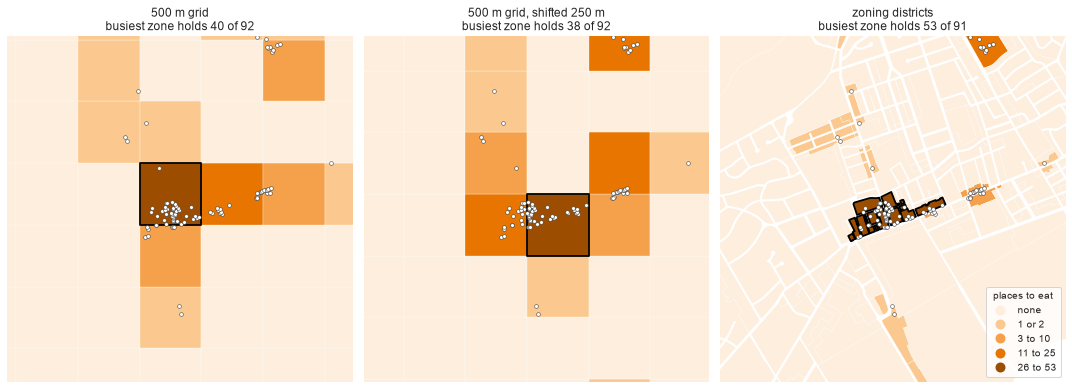

In [6]:
ORANGES = ListedColormap(["#fdeedd", "#fbc98f", "#f5a04a", "#e77500", "#9c4d00"])
PANELS = ("500 m grid", "500 m grid, shifted 250 m", "zoning districts")

counted = {name: count_into(zonings[name], food, "n") for name in PANELS}
top = max(int(c["n"].max()) for c in counted.values())
bins = [0, 2, 10, 25, top]   # one set of class bounds for all three panels, so a colour means the same count in each
labels = ["none", "1 or 2", "3 to 10", "11 to 25", f"26 to {top}"]
mid_x, mid_y = food.geometry.x.median(), food.geometry.y.median()
half = 1400   # metres, so every panel is the same 2.8 km window on the middle of the places to eat

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, name in zip(axes, PANELS):
    c = counted[name]
    c.plot(ax=ax, column="n", cmap=ORANGES, edgecolor="white", linewidth=0.3, scheme="UserDefined", classification_kwds={"bins": bins},
           legend=(name == PANELS[-1]), legend_kwds={"loc": "lower right", "title": "places to eat", "labels": labels})
    c.loc[[c["n"].idxmax()]].plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.8)
    food.plot(ax=ax, color="white", markersize=14, edgecolor="#333333", linewidth=0.5)
    ax.set_title(f"{name}\nbusiest zone holds {c['n'].max()} of {int(c['n'].sum())}")
    ax.set_xlim(mid_x - half, mid_x + half)
    ax.set_ylim(mid_y - half, mid_y + half)
    ax.set_axis_off()
fig.tight_layout()

The dots are the same in all three panels. The outlined zone is not, i.e. a square here, the neighbouring square there, and a long thin ribbon along Nassau Street in the third, each with a different count. A report that said the busiest zone holds 40 of the town's 92 places to eat would be true of the left panel, false of the other two, and silent about which one it meant. The lecture's advice was to state the unit of analysis alongside the number. This is what it looks like when you do not.

## The deer, and three denominators

The municipality publishes the reports it receives about dead deer, a feed of the kind a 311 service produces. In 02-02 the your-turn cell asked which zoning category has the most reports and which has the most per square kilometre, and the point was that the two questions have different answers. Here are both, with a third denominator beside them, i.e. homes, taken as the State file's class 2 dwellings and class 4C apartment buildings, so a block of forty flats counts once. The first printed line states the years the reports span, since the date is the last of the lecture's four questions:

In [7]:
deer = gpd.read_file("data/princeton_municipal.gpkg", layer="deer_reports").to_crs(metric)
tax_roll = gpd.read_file("data/njgin_parcels.gpkg", layer="parcels").to_crs(metric)
print(f"{len(deer)} reports, {deer['year'].min()} to {deer['year'].max()}   reference {reference['deer']['years'][0]} to {reference['deer']['years'][-1]}")

in_zone = gpd.sjoin(deer, zoning[["ZONING_CAT", "geometry"]], predicate="within")
homes = tax_roll[tax_roll["PROP_CLASS"].isin(["2", "4C"])].copy()   # MOD-IV class 2 dwellings and class 4C apartment buildings
homes["geometry"] = homes.geometry.centroid

by_category = pd.DataFrame({
    "reports": in_zone.groupby("ZONING_CAT").size(),
    "km2": zoning.dissolve(by="ZONING_CAT").geometry.area / 1e6,
    "homes": gpd.sjoin(homes[["geometry"]], zoning[["ZONING_CAT", "geometry"]], predicate="within").groupby("ZONING_CAT").size(),
})
by_category["per km2"] = by_category["reports"] / by_category["km2"]
by_category["per 100 homes"] = 100 * by_category["reports"] / by_category["homes"]
by_category.round(1)

492 reports, 2020 to 2024   reference 2020 to 2024


,reports,km2,homes,per km2,per 100 homes
ZONING_CAT,,,,,
BUSINESS-MIXED USE,26,2.0,354,13.2,7.3
CONSERVATION,4,2.5,4,1.6,100.0
EDUCATIONAL,9,5.7,55,1.6,16.4
RESIDENTIAL,289,34.0,6512,8.5,4.4


In [8]:
for column in ("reports", "per km2", "per 100 homes"):
    print(f"most {column:14s} {by_category[column].idxmax()}")

most reports        RESIDENTIAL
most per km2        BUSINESS-MIXED USE
most per 100 homes  CONSERVATION


Three denominators, three leaders. By count the residential category leads, because most of the town is zoned residential and most of everything happens where most of the land is. Per square kilometre the business and mixed-use category leads, because reports are made where people drive and shop, and that category is small and busy. Per hundred homes the conservation category leads, and that is the one to look at hard, because the number under it is tiny. Print the denominators and the winner is a handful of reports divided by a handful of homes.

Here is the wrong intuition executed, i.e. a rate ranked with no floor under its denominator, and then the same ranking with one:

In [9]:
print("ranked by reports per 100 homes, no floor")
print(by_category["per 100 homes"].sort_values(ascending=False).round(1).to_string())
print()
print(f"the smallest denominator in that table is {int(by_category['homes'].min())} homes   reference {reference['deer']['smallest_home_denominator']}")
print()
print("the same ranking, categories with at least 50 homes")
print(by_category.loc[by_category["homes"] >= 50, "per 100 homes"].sort_values(ascending=False).round(1).to_string())

ranked by reports per 100 homes, no floor
ZONING_CAT
CONSERVATION          100.0
EDUCATIONAL            16.4
BUSINESS-MIXED USE      7.3
RESIDENTIAL             4.4

the smallest denominator in that table is 4 homes   reference 4

the same ranking, categories with at least 50 homes
ZONING_CAT
EDUCATIONAL           16.4
BUSINESS-MIXED USE     7.3
RESIDENTIAL            4.4


A rate on a denominator of four is not a rate. It is an anecdote with a decimal point, and it will sit at the top of any ranking that does not ask how big the bottom of the fraction was. Note that the floor of fifty is a decision too, and the caption has to say it. There is no number that makes a small denominator safe, only a stated one.

## A third of the reports belong to no zone

The zoning join placed most of the reports, and the rest fell through. In 02-02 that remainder was a note; here it is the point:

In [10]:
unassigned = deer[~deer.index.isin(in_zone.index)]
roads = gpd.read_file("data/princeton_municipal.gpkg", layer="roads").to_crs(metric)
NEAR_ROAD_M = 15   # a local street reserve is about this wide, so a point this far from the centreline is still in the street
road_lines = roads.union_all()
near_road = deer.geometry.distance(road_lines) < NEAR_ROAD_M

print(f"{len(unassigned)} of {len(deer)} reports lie in no zoning district   reference {reference['deer']['unassigned_to_zoning']}")
print(f"{int(near_road.loc[unassigned.index].sum())} of those lie within {NEAR_ROAD_M} m of a road centreline   reference {reference['deer']['unassigned_within_15m_of_road']}")
print(f"{int(near_road.sum())} of all {len(deer)} reports do   reference {reference['deer']['within_15m_of_road']}")
print(f"{int(near_road.sum() - near_road.loc[unassigned.index].sum())} of the reports the join did place are on the street as well")

164 of 492 reports lie in no zoning district   reference 164
163 of those lie within 15 m of a road centreline   reference 163
203 of all 492 reports do   reference 203
40 of the reports the join did place are on the street as well


A third of the reports, and almost every one of them within fifteen metres of a road centreline. The zoning layer has its roads clipped out, so a report placed on the right of way lies in the white strip between the districts and belongs to nothing. That is not a fault in the layer. A road is not zoned. It is a fault in the question, because every per-category number above was computed on two thirds of the data, and the third that was left out is not a random third. Note that 203 of all the reports lie that close to a centreline, and the last printed line counts the ones the join did place that are on the street as well, which survived only because their address put them on the parcel side of the kerb.

The municipality's own `Category` column says where each deer was, so let us check the story against it:

In [11]:
in_a_district = deer.index.isin(in_zone.index)
pd.crosstab(deer["Category"], pd.Series(in_a_district, index=deer.index, name="in a zoning district"))

in a zoning district,False,True
Category,,
Dead Deer On Private Property,4,114
Dead Deer On Roadway,160,214


Read it by row. By the municipality's own record most reports are of a deer on a roadway, and most of those still landed inside a district, because a report geocoded to a house number falls on the parcel side of the kerb. The third that fell through are the reports placed on the road surface itself. So the per-category counts kept the roadway deer that happened to be recorded at an address and lost the ones recorded where they lay, which is a selection nobody chose. The caption of any per-zone map of these reports has to say that a third of them were on land that belongs to no zone. Left the whole town, right the window on the Engineering Quad that 02-06 used, where the strips between the districts are wide enough to see:

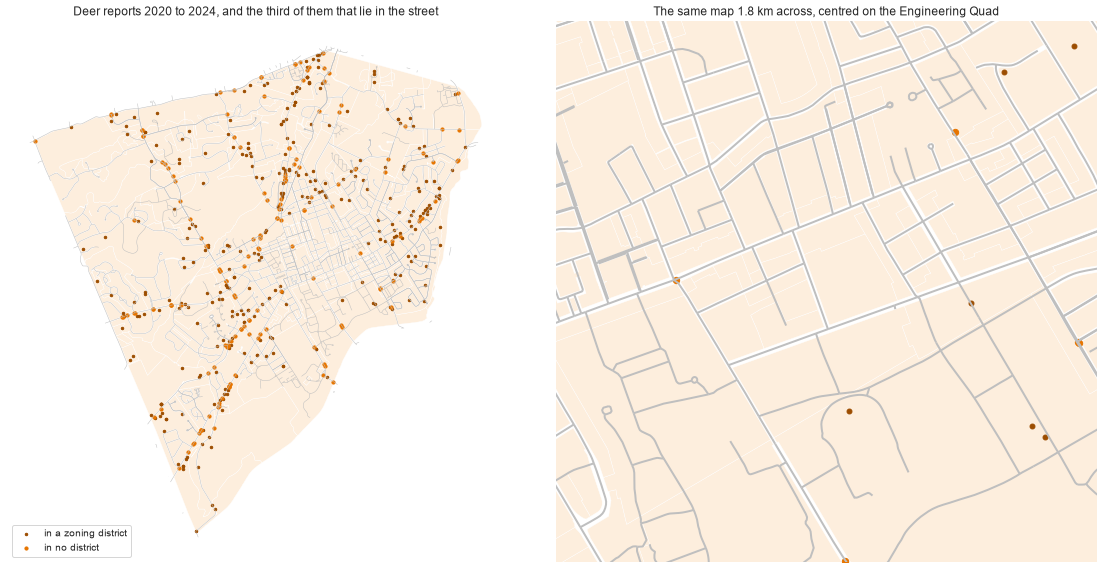

In [12]:
landmarks = pd.read_csv("data/landmarks.csv")
here = landmarks[landmarks["id"] == "e225"].iloc[0]
centre = gpd.GeoSeries.from_xy([here["lon"]], [here["lat"]], crs="EPSG:4326").to_crs(metric).iloc[0]
half = 900   # metres, so the view is 1.8 km across

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, scale in zip(axes, (1, 4)):   # the same layers twice, with the lines and markers scaled up for the window
    zoning.plot(ax=ax, facecolor="#fdeedd", edgecolor="white", linewidth=0.4)
    roads.plot(ax=ax, color="#bfbfbf", linewidth=0.5 * scale)
    deer[deer.index.isin(in_zone.index)].plot(ax=ax, color="#9c4d00", markersize=6 * scale, label="in a zoning district")
    unassigned.plot(ax=ax, color="#e77500", markersize=10 * scale, label="in no district")
    ax.set_axis_off()
axes[0].legend(loc="lower left")
axes[0].set_title(f"Deer reports {deer['year'].min()} to {deer['year'].max()}, and the third of them that lie in the street")
axes[1].set_xlim(centre.x - half, centre.x + half)
axes[1].set_ylim(centre.y - half, centre.y + half)
axes[1].set_title(f"The same map {2 * half / 1000:.1f} km across, centred on the Engineering Quad")
fig.tight_layout()

The lighter points, the ones in no district, are not scattered at random. They draw the street network, which is what a selection looks like when you plot it.

## Per block, and per acre

The tax blocks are the other civic unit, and they stop at the kerb too, so the same third goes missing, which the second printed line checks. What is left can be counted per block and then divided by the block's area, and the two maps disagree the way the count and the rate always do:

In [13]:
in_block = gpd.sjoin(deer[["geometry"]], blocks[["BLOCK_NO", "geometry"]], predicate="within")
per_block = blocks.dissolve(by="BLOCK_NO")[["geometry"]]
per_block["reports"] = in_block.groupby("BLOCK_NO").size()
per_block["per acre"] = per_block["reports"] / (per_block.geometry.area / 4046.856)   # square metres in an acre

print(f"{len(in_block)} reports inside a block, in {per_block['reports'].notna().sum()} of {len(per_block)} blocks   reference {reference['deer']['inside_a_block']}, {reference['deer']['blocks_with_a_report']}")
print(f"{len(set(unassigned.index) - set(in_block.index))} of the {len(unassigned)} reports outside every district are outside every block too")

329 reports inside a block, in 149 of 455 blocks   reference 329, 149
163 of the 164 reports outside every district are outside every block too


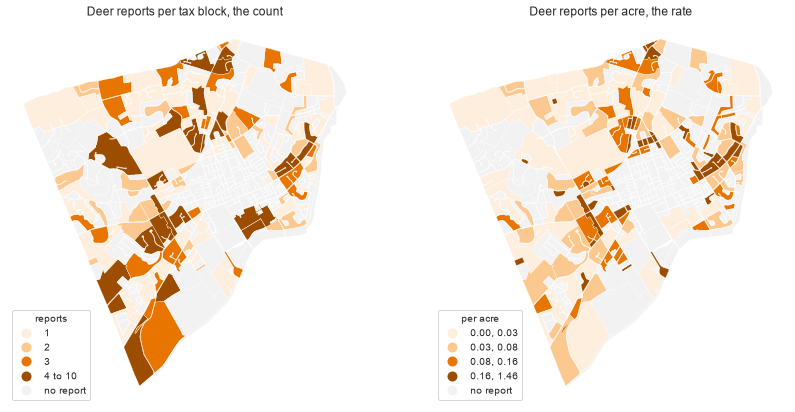

In [14]:
MISSING = {"color": "#f2f2f2", "label": "no report"}
LABELS = (["1", "2", "3", "4 to 10"], None)   # quartiles of small integer counts break at 1, 2, 3 and 10, so the count classes are spelled out
TITLES = ("Deer reports per tax block, the count", "Deer reports per acre, the rate")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, column, fmt, labels, title in zip(axes, ("reports", "per acre"), ("{:.0f}", "{:.2f}"), LABELS, TITLES):
    legend_kwds = {"loc": "lower left", "fmt": fmt, "title": column}
    if labels is not None:
        legend_kwds["labels"] = labels
    per_block.plot(ax=ax, column=column, scheme="Quantiles", k=4, cmap=ORANGES, edgecolor="white", linewidth=0.3,
                   legend=True, missing_kwds=MISSING, legend_kwds=legend_kwds)
    ax.set_title(title)
    ax.set_axis_off()

Left, the count, and the darkest blocks are the big ones, where a single long road collects reports along hundreds of metres of frontage. Right, the rate, and the darkest blocks are small ones near the centre, where one report on a two-acre block is a high rate. Neither map is wrong. Each is a map of its denominator as much as of its numerator, and a reader who is not told which one they are looking at will read the count as intensity and the rate as volume.

## The denominator that is missing

For a report a person makes, one honest denominator is people. A category with many residents and few reports is a different place from one with few residents and the same few reports, and neither area nor homes quite says which is which. The Census publishes people per block group, and the block groups are already in your data folder as shapes. Their population columns arrive with a later pull, once the pipeline has its key to the Census API. Until then, homes stand in for people, and the gap between the two is largest on the campus, where thousands of people live in a handful of buildings that are not homes.

## Your turn

If deer are reported from roads, the natural unit is the road. Assign each report to its nearest road segment with `gpd.sjoin_nearest`, count reports per road class, divide by the kilometres of road in each class, and say which class has the most reports per kilometre. The classes are the Census road codes the municipality's file uses, i.e. `S1200` for secondary roads, `S1400` for local streets and `S1630` for ramps, with a blank for segments whose class was not recorded. Then say what a per-kilometre rate hides that a per-home rate showed.

In [15]:
# Your attempt.
#
#   gpd.sjoin_nearest(deer[["geometry"]], roads[["ROADCLASS", "geometry"]], how="left", distance_col="d")
#   roads.geometry.length.groupby(roads["ROADCLASS"]).sum() / 1000                 kilometres per class
#   a report can tie between two segments at exactly the same distance; keep one row per report

## Check your understanding

1. The same ninety-two places gave a busiest zone holding a sixth of them under one set of lines and more than half under another. What changed, and what would a report have to state for either number to be meaningful?
2. Three denominators gave three different leading categories for the deer reports. For each denominator, name the question it actually answers.
3. A rate ranked the conservation zone first on a denominator of four homes. What is wrong with that, and why does putting a floor under the denominator not fully fix it?
4. A third of the reports fell in no zoning district and nearly all of them lay on a road. Is that a problem with the data, the layer, or the question, and what does it do to every per-zone number?

## Where we are

You have watched one set of points give five answers under five sets of lines, seen the leader move when a grid slides by half a cell, and given the problem its name. You have divided the same reports by three denominators and watched three different places come out on top, and you have caught a rate that was really an anecdote. You have found a third of the data lying in the street, outside every zone, and you know why. You have counted the same reports per block and then per acre, and watched the count map and the rate map disagree the way a count and a rate always do. Every one of those belongs in a caption, and the denominator this folder cannot yet offer you, people, is the one to ask for when the census columns arrive.

## Further resources

Nothing in this course requires anything below.

The modifiable areal unit problem was named and worked through in Openshaw, S. (1984), The Modifiable Areal Unit Problem, Concepts and Techniques in Modern Geography 38, Geo Books, Norwich, and first noticed half a century earlier in Gehlke, C. E. and Biehl, K. (1934), Certain effects of grouping upon the size of the correlation coefficient in census tract material, Journal of the American Statistical Association 29(185), 169 to 170.

The road class codes are the Census Bureau's MAF/TIGER feature class codes, defined here: https://www.census.gov/library/reference/code-lists/mt-feature-class-codes.html

The geopandas documentation for `sjoin_nearest`, which the your-turn cell needs, including how ties are handled: https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin_nearest.html

The places to eat and the buildings behind the grid are from OpenStreetMap, ODbL 1.0; the zoning, blocks, roads and deer reports from the Municipality of Princeton; the parcels from NJGIN Open Data, as listed in the data folder's README.

## Appendix, in case you are stuck

Try properly first. If you do use this, treat it the way you would treat an agent's answer. Read it, run it, and say why yours differed.

```python
import geopandas as gpd
import pandas as pd

metric = "EPSG:26918"
deer = gpd.read_file("data/princeton_municipal.gpkg", layer="deer_reports").to_crs(metric)
roads = gpd.read_file("data/princeton_municipal.gpkg", layer="roads").to_crs(metric)

nearest = gpd.sjoin_nearest(deer[["geometry"]], roads[["ROADCLASS", "geometry"]], how="left", distance_col="d")
nearest = nearest[~nearest.index.duplicated()]          # a report equidistant from two segments counts once

per_class = pd.DataFrame({
    "reports": nearest.groupby("ROADCLASS").size(),
    "road_km": roads.geometry.length.groupby(roads["ROADCLASS"]).sum() / 1000,
})
per_class["per_km"] = per_class["reports"] / per_class["road_km"]
print(per_class.sort_values("per_km", ascending=False).round(2))
print("median distance from a report to its road:", round(nearest["d"].median(), 1), "m")
```

The secondary roads collect several times the reports per kilometre of the local streets, which a per-home rate could not see, because a through road has traffic without homes. The per-home rate could see the campus, which a per-kilometre rate cannot. Neither is the denominator. Each is a denominator, and the caption says which. Note that no report is nearest a ramp, so `groupby` never makes an S1630 group at all and its rate prints as NaN, i.e. a missing group is not a zero.